In [2]:
import os
os.chdir("../ephys_analysis")

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pipelines
# fix slow autocomplete
%config Completer.use_jedi = False
pd.options.display.max_columns=200
pd.options.display.max_rows=300
pd.options.display.max_colwidth=200

from importlib import reload

In [ ]:
df_all = pd.read_csv("~/projects/data/culture/features_ET.csv", index_col=0)
ephys_df = pd.read_csv("~/projects/data/culture/features_E.csv", index_col=0)

ephys_features = [feat for feat in ephys_df.columns if 'qc' not in feat and 'fail' not in feat]

ttype = "topLeaf"

# df_all = df_all.query("subclass=='PVALB' | subclass=='SST'")
df_all = df_all.loc[lambda df: df.layer.isin(['2','3'])]

In [13]:
complete_features = np.array(ephys_features)[(df_all[ephys_features].notna().mean(axis=0)>0.80)]
complete_cells = df_all[complete_features].notna().mean(axis=1).loc[lambda x: x>0.50].index
ivscc_df = df_all.loc[complete_cells]

In [5]:
ivscc_df.to_csv("ivscc_culture_reference.csv")

In [7]:
man_df = pd.read_csv("MET_METc_data_lockdown_210827_all.csv", index_col=0)

In [9]:
man_df.index.intersection(ivscc_df.index).shape[0]

123

In [10]:
ivscc_df.index.difference(man_df.index).shape[0]

15

In [11]:
ivscc_df.loc[ivscc_df.index.difference(man_df.index), '']

,blowout_mv_qc,electrode_0_pa_qc,recording_date_qc,seal_gohm_qc,input_resistance_mohm_qc,initial_access_resistance_mohm_qc,input_access_resistance_ratio_qc,fail_tags_qc,failed_blowout,failed_electrode_0,failed_seal,failed_input_access_resistance,failed_qc,failed_fx_long_squares,failed_fx_short_squares,failed_fx_ramps,failed_fx_chirps,failed_fx_sweep_features,upstroke_downstroke_ratio_ramp,threshold_v_ramp,width_ramp,width_suprathresh_ramp,upstroke_ramp,downstroke_ramp,threshold_i_ramp,trough_deltav_ramp,fast_trough_deltav_ramp,peak_deltav_ramp,upstroke_downstroke_ratio_short_square,threshold_v_short_square,width_short_square,width_suprathresh_short_square,upstroke_short_square,downstroke_short_square,fast_trough_deltav_short_square,peak_deltav_short_square,v_baseline,rheobase_i,fi_fit_slope,sag,sag_peak_t,vm_for_sag,input_resistance,input_resistance_ss,tau,latency_rheo,avg_rate_rheo,mean_isi_rheo,upstroke_downstroke_ratio_rheo,threshold_v_rheo,width_rheo,width_suprathresh_rheo,upstroke_rheo,downstroke_rheo,fast_trough_v_last_rheo,adp_v_last_rheo,adapt_hero,avg_rate_hero,latency_hero,mean_isi_hero,median_isi_hero,isi_cv_hero,upstroke_downstroke_ratio_hero,threshold_v_hero,width_hero,width_suprathresh_hero,upstroke_hero,downstroke_hero,ahp_delay_ratio_hero,sag_depol,sag_peak_t_depol,adapt_mean,isi_cv_mean,isi_adapt_ratio,width_adapt_ratio,upstroke_adapt_ratio,downstroke_adapt_ratio,peak_v_adapt_ratio,threshold_v_adapt_ratio,fast_trough_v_adapt_ratio,ahp_delay_ratio_5spike,trough_deltav_rheo,trough_deltav_hero,fast_trough_deltav_rheo,fast_trough_deltav_hero,peak_deltav_rheo,peak_deltav_hero,first_isi_inv_hero,peak_ratio_chirp,peak_freq_chirp,3db_freq_chirp,peak_impedance_chirp,low_freq_impedance_chirp,sync_freq_chirp,phase_peak_chirp,phase_low_chirp,total_inductive_phase_chirp,exp_component_name,layer,batch,cell_name.1,spec_id,donor,collaborator,gender,collection,medical_conditions,postPatch,postPatch_classification,filldate,rigOperator,rigNumber,cell_depth,sliceHealth,patchseq_roi,roi,Class,injection_roi,injection_method,injection_materials,propagation_type,Total_time,Ephys_time,Retraction_time,endPipetteR,rna_amplification_pass_fail,go_no_go_63x,image_series_63x_qc,cell_specimen_project,percent_reads_aligned_total,percent_reads_aligned_to_exons,genes,patch_date,exclude,fpkm_dir,MALAT1_cpm,Depth_from_Pia_microns,total_cortical_depth,L23_cell_depth,L23_total_thickness,virus,recon_cell_overall_state,recon_layer_type,cluster,score,n_marker,res_index,h_score,res_index_pctile,topLeafValue,last_map,last_res,last_score,code_version,ref_version,mapping_version,sample_id,cell_reporter,marker_genes,topLeaf,quality_score,marker_sum_norm,Norm_Marker_Sum.0.4,contaminationType,contam_sum,seurat_cluster,seurat_prediction_score,broad_class,subclass,Tree_first_cl,Tree_second_cl,Tree_third_cl,Tree_first_bt,Tree_second_bt,Tree_third_bt,Tree_first_KL,Tree_second_KL,Tree_third_KL,Tree_first_cor,Tree_second_cor,Tree_third_cor,Tree_call,Old_call,ac,ac_subclass,leaf_matched_seurat,leaf_mapped,L23_depth_normalized
837579858,NaN,24.935625,2019-03-15 17:48:16,3.673172,178.926656,11.355859,0.063467,NaN,False,False,False,False,False,False,False,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.715942,-40.012501,0.000540,0.000440,333.198831,-194.178358,-26.287495,70.012503,-67.779099,140.000000,0.754305,0.342387,0.04084,-86.512497,160.062477,107.434804,0.011755,0.02418,1.0,NaN,1.300730,-30.931252,0.00072,0.00048,191.296785,-147.068796,-65.875000,NaN,0.004334,35.0,0.01306,0.028404,0.02830,0.085070,1.567868,-35.174999,0.00058,0.00044,278.890967,-177.879152,0.073253,0.050982,0.29266,0.003838,0.050494,1.115385,1.310345,0.630794,0.819601,0.721782,0.832978,1.012016,0.073253,-35.318756,-28.425003,-34.943748,-27.762505,49.731251,61.975000,44.802867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SM-GE4Q8_S082_E1-50,3,RSC-205,H19.03.006.99.01.04.01.01,837579858,NaN,NaN,F,Patch-seq Production,NaN,nucleus_absent,Outside-Out,2/5/2019,lindsayn,3,50.8,2,TCx3,TCx_L3,noclass,N

## Synphys cells

In [4]:
from pathlib import Path
folder = Path("/allen/programs/celltypes/workgroups/hct/Meanhwan/SynPhys/")
cells = [
    ("Synphys_processed/2019_04_08_153129/2019_04_08_153129-compressed.nwb", [2]),
    ("Synphys_processed/2019_06_11_124522/2019_06_11_124522-compressed.nwb", [1]),
    ("Synphys_processed/2020_11_23_142835/2020_11_23_142835-compressed.nwb", [10]),
    ("Synphys_processed/2020_11_24_104003/2020_11_24_104003-compressed.nwb", [1]),
    ("Synphys_processed/2020_11_24_144759/2020_11_24_144759-compressed.nwb", [0]),
    ("Synphys_processed/2020_12_08_094641/2020_12_08_094641-compressed.nwb", [0]),
    ("Synphys_processed/2020_12_09_210145/2020_12_09_210145-compressed.nwb", [10]),
    ("Synphys_processed/2020_12_10_182016/2020_12_10_182016-compressed.nwb", [10]),
    ("Synphys_processed/2020_12_11_102431/2020_12_11_102431-compressed.nwb", [9]),
    ("Synphys_processed/2020_12_21_112503/2020_12_21_112503-compressed.nwb", [0, 2, 11]),
    ("Synphys_processed/2020_12_22_134814/2020_12_22_134814-compressed.nwb", [11]),
    ("Synphys_processed/2020_12_22_202534/2020_12_22_202534-compressed.nwb", [10]),
    ("Synphys_processed/2020_12_23_184436/2020_12_23_184436-compressed.nwb", [0, 1]),
    ("Synphys_processed/2020_12_23_200124/2020_12_23_200124-compressed.nwb", [9]),
    ("Synphys_processed/2020_12_23_205145/2020_12_23_205145-compressed.nwb", [9]),
    ("Synphys_processed/2020_12_24_122924/2020_12_24_122924-compressed.nwb", [0]),
    ("Synphys_processed/2020_12_24_112525/2020_12_24_112525-compressed.nwb", [9]),
    ("Synphys_processed/2021_01_11_132022/2021_01_11_132022-compressed.nwb", [11]),
    ("Synphys_processed/2021_01_14_122423/2021_01_14_122423-compressed.nwb", [2]),
    ("Synphys_processed/2021_01_19_094947/2021_01_19_094947-compressed.nwb", [0]),
    ("Synphys_processed/2021_01_20_172614/2021_01_20_172614-compressed.nwb", [0, 10]),
    ("Synphys_processed/2021_01_20_190535/2021_01_20_190535-compressed.nwb", [1, 2]),
    ("Synphys_processed/2021_04_13_102400/2021_04_13_102400-compressed.nwb", [10]),
    ("Synphys_processed/2021_04_13_161350/2021_04_13_161350-compressed.nwb", [2]),
    ("Synphys_processed/2021_06_30_152235/2021_06_30_152235-compressed.nwb", [10]),
    ("Synphys_processed/2018_08_10_123831/2018_08_10_123831-compressed.nwb", [8, 11]),
    ("Synphys_processed/2019_01_29_153525/2019_01_29_153525-compressed.nwb", [8]),
    ("Synphys_processed/2019_09_24_152940/2019_09_24_152940-compressed.nwb", [10]),
    ("Synphys_processed/2019_09_27_153408/2019_09_27_153408-compressed.nwb", [0, 1, 3, 10]),
    ("Synphys_processed/2018_09_18_111648/2018_09_18_111648-compressed.nwb", [0, 1, 2, 3, 8, 9, 10, 11]),
    ("Synphys_processed/2018_09_18_151319/2018_09_18_151319-compressed.nwb", [2, 8, 9, 11]),
    ("Synphys_processed/2018_09_19_123218/2018_09_19_123218-compressed.nwb", [3]),
    ("Synphys_processed/2018_11_26_132347/2018_11_26_132347-compressed.nwb", [8, 11]),
    ("Synphys_processed/2018_11_26_154158/2018_11_26_154158-compressed.nwb", [0, 2, 3, 10]),
    ("Synphys_processed/2018_08_08_012128/2018_08_08_012128-compressed.nwb", [3]),
    ("Synphys_processed/2018_09_11_204723/2018_09_11_204723-compressed.nwb", [1]),
    ("Synphys_processed/2018_09_11_223732/2018_09_11_223732-compressed.nwb", [0]),
    
    ("Synphys_processed/2020_12_23_101158/2020_12_23_101158-compressed.nwb", [2]),
    ("Synphys_processed/2021_09_21_142913/2021_09_21_142913-compressed.nwb", [11]),
    ("Synphys_processed/2018_12_17_151610/2018_12_17_151610-compressed.nwb", [9]),
    ("Synphys_processed/2018_12_18_150159/2018_12_18_150159-compressed.nwb", [2]),
    ("Synphys_processed/2019_09_24_152940/2019_09_24_152940-compressed.nwb", [8, 10]),
    ("Synphys_processed/2019_10_02_163453/2019_10_02_163453-compressed.nwb", [3]),
    ("Synphys_processed/2021_07_27_163747/2021_07_27_163747-compressed.nwb", [10]),
    ("Synphys_processed/2021_07_28_164640/2021_07_28_164640-compressed.nwb", [1, 11]),
    ("Synphys_processed/2021_08_03_095510/2021_08_03_095510-compressed.nwb", [0]),
    ("Synphys_processed/2021_09_01_121758/2021_09_01_121758-compressed.nwb", [11]),
    ("Synphys_processed/2021_09_01_155124/2021_09_01_155124-compressed.nwb", [3]),
    ("Synphys_processed/2020_12_18_090358/2020_12_18_090358-compressed.nwb", [9]),
    ("Synphys_processed/2020_12_22_182422/2020_12_22_182422-compressed.nwb", [0]),
    ("Synphys_processed/2020_12_23_101158/2020_12_23_101158-compressed.nwb", [2]),
    ("2021.01.15_000/slice_000/site_001/2021_01_15_173921-compressed.nwb", [9]),
    ("2020.12.08_000/slice_000/site_002/2020_12_08_132441-compressed.nwb", [2]),
]

In [5]:
from aisynphys.intrinsic_ephys import features_from_nwb
from itertools import chain
import os.path
import pandas as pd

def process_file_list(files, channels_list=None, output=None):
    if channels_list:
        records = chain(*(features_from_nwb(folder/file, channels) 
                          for file, channels in zip(files, channels_list)))
    else:
        records = chain(*(features_from_nwb(os.path.join(folder, file)) for file in files))
    ephys_df = pd.DataFrame.from_records(records)
    if output:
        ephys_df.to_csv(output)
    return ephys_df

In [6]:
synphys_cell_df = process_file_list(*zip(*cells))

In [7]:
synphys_cell_df.to_csv('data/synphys_culture_intrinsic_2021_10_13.csv')

## start from load...

In [5]:
synphys_cell_df = pd.read_csv('data/synphys_culture_intrinsic_2021_10_13.csv', index_col=0)

In [6]:
synphys_cell_df.notna().mean(axis=1).value_counts().sort_index()

0.046875     3
0.187500     4
0.328125     1
0.375000     1
0.703125     1
0.734375     1
0.796875     1
0.812500     2
0.828125     7
0.843750    12
0.859375     7
0.921875     1
0.937500     1
0.953125     2
0.968750    11
0.984375    14
1.000000     9
dtype: int64

In [8]:
synphys_cell_df.notna().mean(axis=0).sort_values().head(15)

adp_v_last_rheo                0.423077
mean_isi_rheo                  0.487179
total_inductive_phase_chirp    0.551282
phase_peak_chirp               0.551282
sync_freq_chirp                0.551282
low_freq_impedance_chirp       0.551282
peak_impedance_chirp           0.551282
3db_freq_chirp                 0.551282
peak_freq_chirp                0.551282
phase_low_chirp                0.551282
peak_ratio_chirp               0.551282
adapt_hero                     0.794872
peak_v_adapt_ratio             0.846154
downstroke_adapt_ratio         0.846154
isi_adapt_ratio                0.846154
dtype: float64

In [9]:
print(synphys_cell_df.shape)
synphys_complete = (synphys_cell_df
                    .loc[lambda df: df.notna().mean(axis=1) > 0.5]
                    .loc[:, lambda df: df.notna().mean(axis=0) > 0.8]
                   )
synphys_complete.filename = synphys_complete.filename.apply(lambda x: str(x).split('/')[-2])
synphys_complete.set_index(['filename','channel','device'], inplace=True)
print(synphys_complete.shape)
synphys_complete.head()

(78, 64)
(69, 50)


,,,v_baseline,sag,sag_peak_t,vm_for_sag,input_resistance,input_resistance_ss,tau,sag_depol,sag_peak_t_depol,rheobase_i,fi_fit_slope,latency_rheo,avg_rate_rheo,upstroke_downstroke_ratio_rheo,threshold_v_rheo,width_rheo,width_suprathresh_rheo,upstroke_rheo,downstroke_rheo,fast_trough_v_last_rheo,adapt_hero,avg_rate_hero,latency_hero,mean_isi_hero,median_isi_hero,isi_cv_hero,upstroke_downstroke_ratio_hero,threshold_v_hero,width_hero,width_suprathresh_hero,upstroke_hero,downstroke_hero,ahp_delay_ratio_hero,adapt_mean,isi_cv_mean,isi_adapt_ratio,width_adapt_ratio,upstroke_adapt_ratio,downstroke_adapt_ratio,peak_v_adapt_ratio,threshold_v_adapt_ratio,fast_trough_v_adapt_ratio,ahp_delay_ratio_5spike,trough_deltav_rheo,trough_deltav_hero,fast_trough_deltav_rheo,fast_trough_deltav_hero,peak_deltav_rheo,peak_deltav_hero,first_isi_inv_hero
filename,channel,device,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019_06_11_124522,1,1,-68.681688,0.181606,0.07342,-86.281258,188.379556,158.600069,0.021834,0.658513,0.19606,178.499985,0.583559,0.02888,2.0,2.292185,-32.437504,0.00084,0.00070,228.257078,-99.580583,-53.474998,0.022112,38.0,0.01570,0.025753,0.026390,0.183385,2.379951,-34.649998,0.00082,0.00068,239.206224,-100.508878,0.071695,0.025883,0.144536,5.758874,1.095238,0.825059,0.925205,0.936357,0.900222,0.993387,0.021679,-21.106251,-18.656254,-21.037495,-18.637505,57.693756,60.293749,81.168831
2020_11_23_142835,10,6,-71.077498,0.220139,0.02292,-91.581253,101.072595,84.845020,NaN,0.404563,0.03646,178.499985,0.493728,0.02948,2.0,1.899203,-39.700001,0.00042,0.00038,425.993186,-224.301023,-57.612499,0.051062,22.0,0.01762,0.046004,0.045820,0.340296,1.908996,-41.831253,0.00042,0.00038,436.938232,-228.883829,0.019034,0.046588,0.247531,1.723159,1.047619,0.941529,0.963321,0.982198,0.915583,1.007164,0.019034,-18.000004,-15.837502,-17.912498,-15.750000,69.825003,72.025005,44.365572
2020_12_08_094641,0,0,-71.904339,0.480478,0.02934,-86.699997,251.180202,150.560841,0.006725,0.267314,0.25914,63.000000,0.747225,0.02500,4.0,2.364198,-47.556255,0.00060,0.00056,277.056241,-117.188247,-51.450005,0.035040,50.0,0.00952,0.020003,0.020880,0.255666,2.392853,-47.712505,0.00058,0.00056,287.141960,-119.999809,0.142050,0.122882,0.381043,28.534615,1.100000,0.875761,0.893611,0.935433,0.992623,1.029412,0.179000,-4.587498,-3.899994,-4.549999,-3.781246,63.300007,63.912508,213.675214
2020_12_09_210145,10,6,-70.500324,0.054465,0.22013,-83.662506,442.660749,420.138876,0.030567,0.069426,0.27873,31.500000,0.620155,0.16723,6.0,2.170847,-43.468750,0.00094,0.00077,204.870819,-94.373671,-64.143753,0.008844,20.0,0.04715,0.046582,0.046670,0.053291,2.158277,-42.606255,0.00090,0.00074,217.186126,-100.629386,0.086133,0.015104,0.060297,1.068453,1.054348,0.888068,0.948528,0.968615,0.964353,0.975591,0.061362,-22.662498,-21.849998,-21.743752,-21.224998,59.368751,59.768757,22.507315
2020_12_10_182016,10,6,-70.382341,0.182941,0.04522,-89.231255,88.019684,76.734023,0.010280,0.242246,0.13326,136.500000,0.158286,0.04788,6.0,3.297961,-47.793755,0.00085,0.00079,293.905186,-89.117244,-53.218754,0.053854,18.0,0.02122,0.055116,0.057875,0.185270,3.459455,-47.706249,0.00082,0.00077,319.999992,-92.500116,0.256410,0.046059,0.174414,1.621168,1.108434,0.844553,0.858617,0.937749,0.982382,0.969111,0.169022,-9.624996,-7.106255,-6.781250,-6.500004,74.631256,74.031252,33.322226


## Merged dataset

In [14]:
set(synphys_complete.columns).difference(complete_features)

set()

In [15]:
set(complete_features).difference(set(synphys_complete.columns))

{'downstroke_ramp',
 'downstroke_short_square',
 'fast_trough_deltav_ramp',
 'fast_trough_deltav_short_square',
 'peak_deltav_ramp',
 'peak_deltav_short_square',
 'threshold_i_ramp',
 'threshold_v_ramp',
 'threshold_v_short_square',
 'trough_deltav_ramp',
 'upstroke_downstroke_ratio_ramp',
 'upstroke_downstroke_ratio_short_square',
 'upstroke_ramp',
 'upstroke_short_square',
 'width_ramp',
 'width_short_square',
 'width_suprathresh_ramp',
 'width_suprathresh_short_square'}

In [16]:
exclude = ['v_baseline']
# (holding is explicitly different)
shared_features = list(set(synphys_complete.columns).difference(exclude))

In [17]:
synphys_complete[shared_features].notna().mean(axis=1).value_counts().sort_index()

0.653061     1
0.775510     1
0.816327     2
0.836735     1
0.938776     4
0.959184     1
0.979592     6
1.000000    53
dtype: int64

In [18]:
ivscc_df[shared_features].notna().mean(axis=1).value_counts().sort_index()

0.795918      1
0.877551      4
0.959184      2
0.979592      7
1.000000    124
dtype: int64

In [19]:
combined = pd.concat([ivscc_df, synphys_complete], sort=False)
# combined.subclass.fillna('MPC', inplace=True)
# combined.cell_specimen_project.fillna('MPC', inplace=True)

### visualize all features

In [20]:
from umap import UMAP
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, StandardScaler

In [21]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute1', KNNImputer()),
    ('umap', UMAP(n_neighbors=10, min_dist=0.25))
])

(1.932288682460785, 8.937038624286652, -0.5768222197890283, 6.42792772203684)

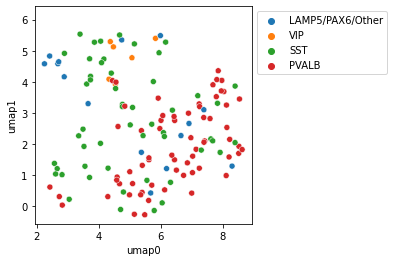

In [22]:
X = combined[shared_features].values
Y = pipeline.fit_transform(X)

combined['umap0'], combined['umap1'] = Y.T

sns.scatterplot(data=combined, x='umap0', y='umap1', hue='subclass')
plt.legend(bbox_to_anchor=(1,1))
plt.axis('square')

In [33]:
# fit to IVSCC then project synphys
synphys = (combined['subclass']=='synphys')
Y = pipeline.fit_transform(combined.loc[~synphys, shared_features].values)
combined['umap0_2'] = np.nan
combined['umap1_2'] = np.nan
combined.loc[~synphys, ['umap0_2','umap1_2']] = Y
Y = pipeline.transform(combined.loc[synphys, shared_features].values)
combined.loc[synphys, ['umap0_2','umap1_2']] = Y

ValueError: Found array with 0 sample(s) (shape=(0, 49)) while a minimum of 1 is required by RobustScaler.

In [ ]:
sns.scatterplot(data=combined, x='umap0_2', y='umap1_2', hue='subclass')
plt.legend(bbox_to_anchor=(1,1))
plt.axis('square')

### restricted features

In [28]:
import regressions as reg
md_features = ['cell_specimen_project']
groups = None
features = shared_features
df = combined
combined.cell_specimen_project.fillna('MPC', inplace=True)

In [29]:
combined['pv_label'] = combined['subclass'].map(lambda x: 'PV' if x=='PVALB' else 'non-PV' if x is not np.nan else None)
combined['pv_label'].value_counts(dropna=False)

non-PV    73
NaN       69
PV        65
Name: pv_label, dtype: int64

In [30]:
results = reg.run_regressions(reg.ols, combined, features, md_features, groups, categorical=True)

results.sort_values('rsquared')

,feature,model,nobs,rsquared,pval
45,fast_trough_v_last_rheo,cell_specimen_project,205.0,4.070944e-07,9.933003e-01
46,fi_fit_slope,cell_specimen_project,207.0,9.621102e-05,9.181523e-01
19,width_adapt_ratio,cell_specimen_project,203.0,2.037103e-04,8.834139e-01
20,upstroke_adapt_ratio,cell_specimen_project,203.0,3.353789e-04,8.411921e-01
32,isi_cv_hero,cell_specimen_project,202.0,5.644685e-04,8.013487e-01
18,threshold_v_adapt_ratio,cell_specimen_project,203.0,9.292287e-04,7.045470e-01
27,adapt_mean,cell_specimen_project,205.0,1.211240e-03,7.045470e-01
1,input_resistance,cell_specimen_project,200.0,1.332549e-03,7.631796e-01
37,latency_hero,cell_specimen_project,207.0,1.344884e-03,7.045470e-01
14,isi_cv_mean,cell_specimen_project,207.0,2.216221e-03,5.785738e-01


In [31]:
restricted_features = results.loc[results.rsquared<0.05, 'feature']
restricted_features.to_list()

['mean_isi_hero',
 'latency_rheo',
 'peak_deltav_hero',
 'sag_peak_t',
 'peak_deltav_rheo',
 'input_resistance_ss',
 'fast_trough_v_adapt_ratio',
 'adapt_hero',
 'isi_adapt_ratio',
 'peak_v_adapt_ratio',
 'sag_peak_t_depol',
 'downstroke_adapt_ratio',
 'vm_for_sag',
 'isi_cv_mean',
 'sag_depol',
 'tau',
 'adapt_mean',
 'latency_hero',
 'threshold_v_adapt_ratio',
 'input_resistance',
 'isi_cv_hero',
 'upstroke_adapt_ratio',
 'width_adapt_ratio',
 'fi_fit_slope',
 'fast_trough_v_last_rheo']

In [45]:
X = combined[restricted_features].values
Y = pipeline.fit_transform(X)

combined['umap0'], combined['umap1'] = Y.T

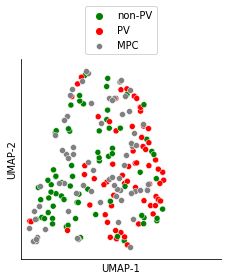

In [55]:
sns.scatterplot(data=combined, x='umap0', y='umap1', hue='pv_label', palette={'PV':'red','non-PV':'green'})
sns.scatterplot(data=combined.loc[combined.subclass.isna()], x='umap0', y='umap1', color='grey', label='MPC')
sns.despine()
name="UMAP"
plt.xlabel(f'{name}-1')
plt.ylabel(f'{name}-2')
plt.xticks([])
plt.yticks([])
plt.legend(loc='lower center', bbox_to_anchor=(0.5,1))
plt.axis('square')
plt.tight_layout()
plt.savefig('/home/tom.chartrand/figs/MPC_intrinsic_umap.pdf')

In [56]:
combined.to_csv('data/synphs_classifier_umap.csv')

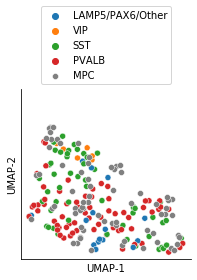

In [38]:
sns.scatterplot(data=combined, x='umap0', y='umap1', hue='subclass')
sns.scatterplot(data=combined.loc[combined.subclass.isna()], x='umap0', y='umap1', color='grey', label='MPC')
sns.despine()
name="UMAP"
plt.xlabel(f'{name}-1')
plt.ylabel(f'{name}-2')
plt.xticks([])
plt.yticks([])
plt.legend(loc='lower center', bbox_to_anchor=(0.5,1))
plt.axis('square')
plt.tight_layout()
plt.savefig('/home/tom.chartrand/figs/MPC_intrinsic_umap.pdf')

## Classifier

In [23]:
data = ivscc_df.sample(frac=1)
data['pv'] = (data.subclass=='PVALB')
print(f"Discarded {len(df_all.index)-len(complete_cells)}/{len(df_all.index)} cells.")
print('Discarded features:')
data[ephys_features].notna().mean(axis=0)[[
    feat for feat in ephys_features if feat not in complete_features]]

Discarded 6/144 cells.
Discarded features:


mean_isi_rheo                  0.449275
adp_v_last_rheo                0.340580
peak_ratio_chirp               0.246377
peak_freq_chirp                0.246377
3db_freq_chirp                 0.246377
peak_impedance_chirp           0.246377
low_freq_impedance_chirp       0.246377
sync_freq_chirp                0.246377
phase_peak_chirp               0.246377
phase_low_chirp                0.246377
total_inductive_phase_chirp    0.246377
dtype: float64

In [24]:
data.subclass.value_counts(normalize=True)

PVALB               0.471014
SST                 0.376812
LAMP5/PAX6/Other    0.108696
VIP                 0.043478
Name: subclass, dtype: float64

In [25]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression

def score_pipeline(pipeline, data, features, cluster_label, cv=None, scoring=None):
    X = data[features].values
    types = data[cluster_label].astype('category')
    y = types.cat.codes
    pipeline.fit(X, y)
    scores = cross_val_score(pipeline, X, y, scoring=scoring, cv=cv)
    print("CV accuracy: {:.2f}+/-{:.2f}".format(np.mean(scores), np.std(scores)))

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, LeaveOneOut
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

## Train calibrated classifier

/local1/storage/envs/ipfx3/lib/python3.7/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


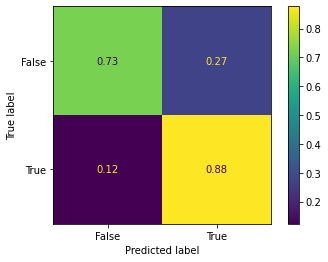

In [32]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', LinearDiscriminantAnalysis(shrinkage='auto', solver='eigen'))
])
exclude = ['vm_for_sag']
features = [x for x in restricted_features if x not in exclude]
cluster_label = 'pv'

cclf = CalibratedClassifierCV(pipeline)
X = data[features].values
types = data[cluster_label].astype('category')
y = types.cat.codes
cclf.fit(X, y)
prob = cclf.predict_proba(X)
# data['subclass_prob'] = prob
data['subclass_prob'] = np.max(prob, axis=1)

from sklearn.metrics import plot_confusion_matrix
labels = types.cat.categories
plot_confusion_matrix(cclf, X, y, display_labels=labels, normalize='true')

In [33]:
pipeline.fit(X, y)
clf = pipeline['class']
# pd.Series(index=features, data=clf.feature_importances_).sort_values(ascending=False)
pd.Series(index=features, data=np.abs(clf.coef_[0])).sort_values(ascending=False)

peak_deltav_rheo             1.018102
sag_depol                    0.946880
upstroke_adapt_ratio         0.696121
tau                          0.586977
fi_fit_slope                 0.446189
downstroke_adapt_ratio       0.393441
input_resistance             0.381634
threshold_v_adapt_ratio      0.376394
fast_trough_v_last_rheo      0.298523
isi_cv_mean                  0.284843
fast_trough_v_adapt_ratio    0.219969
width_adapt_ratio            0.197607
input_resistance_ss          0.192592
peak_v_adapt_ratio           0.153465
adapt_mean                   0.146462
sag_peak_t_depol             0.138321
mean_isi_hero                0.111410
isi_adapt_ratio              0.110781
adapt_hero                   0.083049
isi_cv_hero                  0.079883
latency_rheo                 0.059851
sag_peak_t                   0.055374
peak_deltav_hero             0.027617
latency_hero                 0.018279
dtype: float64

In [32]:
pipeline.fit(X, y)
clf = pipeline['class']
x = pd.Series(index=features, data=clf.coef_[0])
x[x.abs().argsort()[::-1]]

peak_deltav_rheo            -1.018102
sag_depol                    0.946880
upstroke_adapt_ratio         0.696121
tau                         -0.586977
fi_fit_slope                 0.446189
downstroke_adapt_ratio       0.393441
input_resistance            -0.381634
threshold_v_adapt_ratio     -0.376394
fast_trough_v_last_rheo     -0.298523
isi_cv_mean                  0.284843
fast_trough_v_adapt_ratio    0.219969
width_adapt_ratio           -0.197607
input_resistance_ss         -0.192592
peak_v_adapt_ratio          -0.153465
adapt_mean                  -0.146462
sag_peak_t_depol            -0.138321
mean_isi_hero                0.111410
isi_adapt_ratio              0.110781
adapt_hero                  -0.083049
isi_cv_hero                 -0.079883
latency_rheo                 0.059851
sag_peak_t                   0.055374
peak_deltav_hero            -0.027617
latency_hero                -0.018279
dtype: float64

CV accuracy: 0.76+/-0.08


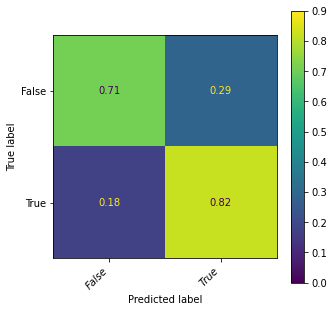

In [34]:
cv = RepeatedStratifiedKFold()
pipelines.plot_cm(cclf, data, features, cluster_label, cv=cv)

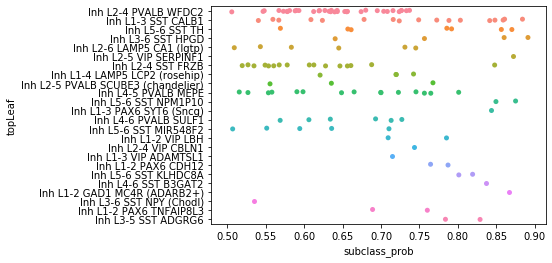

In [60]:
sns.stripplot(data=data, x='subclass_prob', y='topLeaf')

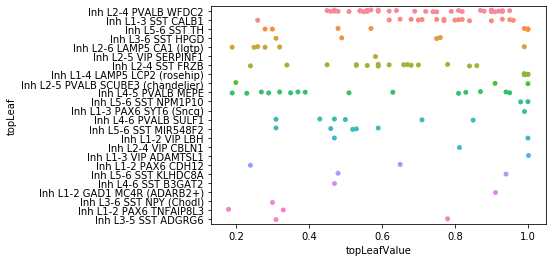

In [61]:
sns.stripplot(data=data, x='topLeafValue', y='topLeaf')

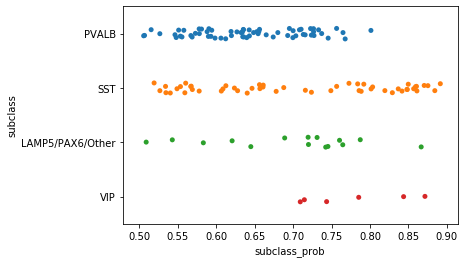

In [62]:
sns.stripplot(data=data, x='subclass_prob', y='subclass')

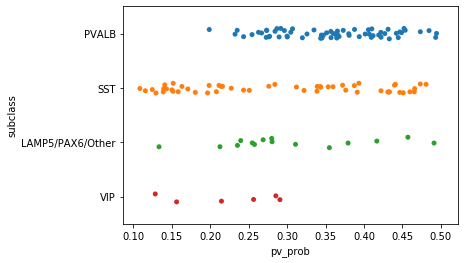

In [63]:
data['pv_prob'] = 1-data['subclass_prob']
sns.stripplot(data=data, x='pv_prob', y='subclass')

Text(0.5, 1.0, 'AP height')

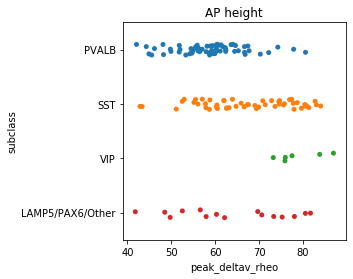

In [67]:
plt.figure(figsize=(4,4))
sns.stripplot(data=data, x='peak_deltav_rheo', y='subclass')
plt.title('AP height')

Text(0.5, 1.0, 'Depol. hump')

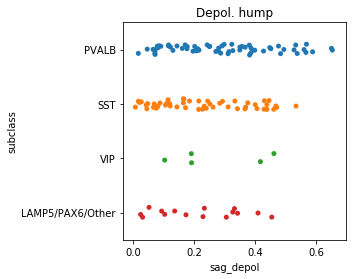

In [68]:
plt.figure(figsize=(4,4))
sns.stripplot(data=data, x='sag_depol', y='subclass')
plt.title('Depol. hump')

### Predict synphys cells

In [65]:
X1 = combined.loc[synphys, features]
y = cclf.predict_proba(X1)[:,1]

# y = (y - y.min())/(y.max() - y.min())
sns.stripplot(x=y)
# sns.ecdfplot(y[:,1])
plt.xlim(0,1)
plt.xlabel("PV Probability")

ValueError: Found array with 0 sample(s) (shape=(0, 24)) while a minimum of 1 is required.

In [62]:
synphys_complete['pv_prob'] = y
synphys_complete['pv'] = pd.cut(y, [0, 0.4, 0.6, 1], include_lowest=True, labels=['false', 'uncertain', 'true'])
synphys_complete.to_csv('data/synphs_ttype_prediction_2021_10_13.csv')

In [61]:
synphys_complete.tail(10)

v_baseline       sag  sag_peak_t  \
filename          channel device                                     
2021_07_28_164640 1       1       -72.475930  0.411749    0.020890   
                  11      7       -70.020444  0.333739    0.017420   
2021_08_03_095510 0       0       -69.645691  0.207067    0.046310   
2021_09_01_121758 11      7       -70.820664  0.404877    0.040620   
2021_09_01_155124 3       3       -71.152191  0.278533    0.020470   
2020_12_18_090358 9       5       -68.505058  0.079124    0.075380   
2020_12_22_182422 0       0       -64.917719  0.223084    0.113240   
2020_12_23_101158 2       2       -69.741128  0.165035    0.049860   
site_001          9       5       -63.801459  0.079496    0.019415   
site_002          2       2       -63.114242  0.166070    0.034540   

                                  vm_for_sag  input_resistance  \
filename          channel device                                 
2021_07_28_164640 1       1      -101.625000        280.303299   
                  11      7       -92.718758         67.993268   
2021_08_03_095510 0       0       -88.143761        110.324137   
2021_09_01_121758 11      7       -97.156258        222.130060   
2021_09_01_155124 3       3       -95.393753         74.309148   
2020_12_18_090358 9       5       -84.068756        142.491132   
2020_12_22_182422 0       0       -84.675003        118.634723   
2020_12_23_101158 2       2       -89.287506        156.775668   
site_001          9       5       -87.412506         38.282756   
site_002          2       2       -96.118759        132.582545   

                                  input_resistance_ss       tau  sag_depol  \
filename          channel device                                             
2021_07_28_164640 1       1                159.517419  0.008437   0.407649   
                  11      7                 42.179405  0.006763   0.397331   
2021_08_03_095510 0       0                 86.505590  0.014567  -0.002355   
2021_09_01_121758 11      7                129.965689  0.015003   0.126420   
2021_09_01_155124 3       3                 55.364697  0.005412   0.224546   
2020_12_18_090358 9       5                136.315215  0.014358   0.170084   
2020_12_22_182422 0       0                 93.272264  0.009224   0.301390   
2020_12_23_101158 2       2                117.270454  0.016087   0.243549   
site_001          9       5                 30.712340  0.007508   0.422645   
site_002          2       2                111.459698  0.004103   0.874368   

                                  sag_peak_t_depol  rheobase_i  fi_fit_slope  \
filename          channel device                                               
2021_07_28_164640 1       1               0.026810        63.0      1.023546   
                  11      7               0.067090       304.5      0.376223   
2021_08_03_095510 0       0               0.499870        73.5      0.315229   
2021_09_01_121758 11      7               0.436120        42.0      0.629207   
2021_09_01_155124 3       3               0.031330       189.0      0.484270   
2020_12_18_090358 9       5               0.067665        73.5      0.616810   
2020_12_22_182422 0       0               0.123220       136.5      0.415601   
2020_12_23_101158 2       2               0.128220        63.0      0.476460   
site_001          9       5               0.037115       388.5      0.138795   
site_002          2       2               0.018440       168.0      0.116528   

                                  latency_rheo  avg_rate_rheo  \
filename          channel device                                
2021_07_28_164640 1       1           0.024850            2.0   
                  11      7           0.024490            2.0   
2021_08_03_095510 0       0           0.127950            4.0   
2021_09_01_121758 11      7           0.156940            2.0   
2021_09_01_155124 3       3           0.022400            2.0   
2020_12_18_090358 9       5           0.061065 

Text(0.5, 0, 'PV Probability')

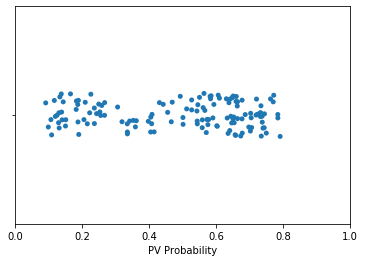

In [56]:
y = cclf.predict_proba(X)[:,1]
# y = (y - y.min())/(y.max() - y.min())
sns.stripplot(x=y)
# sns.ecdfplot(y)
plt.xlim(0,1)
plt.xlabel("PV Probability")

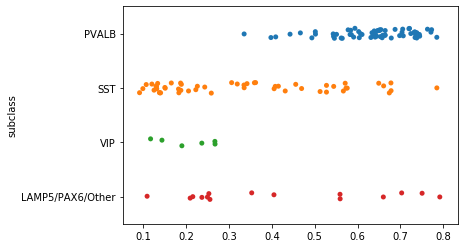

In [57]:
sns.stripplot(data=data, x=y, y='subclass')

## Compare RF / complete features

In [36]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', LinearDiscriminantAnalysis(shrinkage='auto', solver='eigen'))
    # ('class', RandomForestClassifier(class_weight='balanced'))
])
features = complete_features
cluster_label = 'pv'

cclf = CalibratedClassifierCV(pipeline)
X = data[features].values
types = data[cluster_label].astype('category')
y = types.cat.codes
cclf.fit(X, y)
prob = cclf.predict_proba(X)
data['subclass_prob'] = np.max(prob, axis=1)

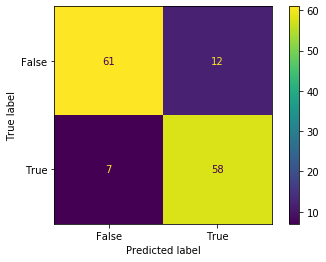

In [37]:
from sklearn.metrics import plot_confusion_matrix
labels = types.cat.categories
plot_confusion_matrix(cclf, X, y, display_labels=labels)

In [38]:
pipeline.fit(X, y)
clf = pipeline['class']
x = pd.Series(index=features, data=clf.coef_[0])
x[x.abs().argsort()[::-1]]

sag_depol                                 1.171952
peak_deltav_rheo                         -0.672599
downstroke_hero                          -0.669437
peak_deltav_ramp                         -0.669385
downstroke_rheo                          -0.656888
upstroke_adapt_ratio                      0.590315
width_suprathresh_rheo                   -0.586536
upstroke_ramp                            -0.584767
downstroke_ramp                          -0.571521
threshold_v_hero                         -0.535818
vm_for_sag                                0.529139
latency_rheo                              0.494753
input_resistance                          0.475973
sag                                      -0.470020
input_resistance_ss                       0.435087
threshold_v_rheo                          0.430187
downstroke_short_square                  -0.405863
fast_trough_deltav_ramp                  -0.398775
median_isi_hero                          -0.396542
ahp_delay_ratio_5spike         

CV accuracy: 0.77+/-0.07


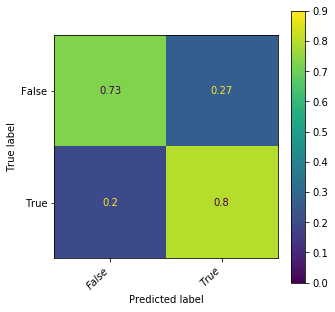

In [132]:
cv = RepeatedStratifiedKFold()
pipelines.plot_cm(cclf, data, features, cluster_label, cv=cv)

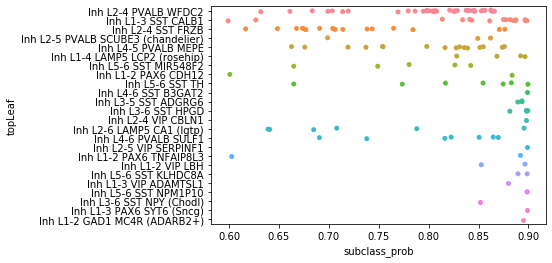

In [115]:
sns.stripplot(data=data, x='subclass_prob', y='topLeaf')

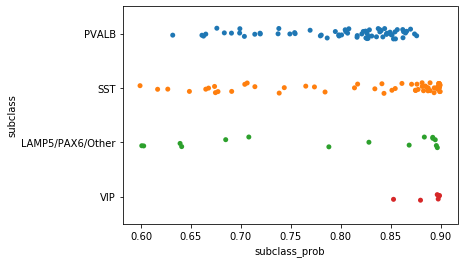

In [116]:
sns.stripplot(data=data, x='subclass_prob', y='subclass')

## classifier comparison

No obvious effect of larger (sparse) feature set or imputation method

In [32]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute1', KNNImputer()),
    ('class', LogisticRegression(class_weight='balanced'))
])
score_pipeline(pipeline, data, shared_features, "pv", cv=RepeatedStratifiedKFold())

CV accuracy: 0.77+/-0.09


Different classifiers:

In [73]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', KNeighborsClassifier())
])
score_pipeline(pipeline, data, shared_features, "pv", cv=RepeatedStratifiedKFold())

CV accuracy: 0.71+/-0.08


In [74]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', LinearDiscriminantAnalysis(shrinkage='auto', solver='eigen'))
])
score_pipeline(pipeline, data, shared_features, "pv", cv=RepeatedStratifiedKFold())

CV accuracy: 0.79+/-0.07


In [75]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', RandomForestClassifier(class_weight='balanced'))
])
score_pipeline(pipeline, data, shared_features, "pv", cv=RepeatedStratifiedKFold())

CV accuracy: 0.76+/-0.07


In [76]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', GaussianNB())
])
score_pipeline(pipeline, data, shared_features, "pv", cv=RepeatedStratifiedKFold())

CV accuracy: 0.77+/-0.08


Restricted features

In [119]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', LinearDiscriminantAnalysis(shrinkage='auto', solver='eigen'))
])
score_pipeline(pipeline, data, features, "pv", cv=RepeatedStratifiedKFold())

CV accuracy: 0.78+/-0.08


In [120]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', RandomForestClassifier(class_weight='balanced'))
])
score_pipeline(pipeline, data, features, "pv", cv=RepeatedStratifiedKFold())

CV accuracy: 0.76+/-0.08


In [121]:
pipeline = Pipeline(steps=[
    ('norm', RobustScaler()),
    ('impute', KNNImputer()),
    ('class', GaussianNB())
])
score_pipeline(pipeline, data, features, "pv", cv=RepeatedStratifiedKFold())

CV accuracy: 0.74+/-0.08
